In [19]:
from __future__ import annotations

import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

# Ensure Eigen headers are discoverable for optional C++ extension build
for _cand in (
    "/usr/include/eigen3",
    "/usr/local/include/eigen3",
    str(Path.home() / ".local" / "eigen-src" / "eigen-3.4.0"),
):
    if os.path.isfile(f"{_cand}/Eigen/Core"):
        os.environ.setdefault("EIGEN_INCLUDE", _cand)
        break

# Ensure local negf package is on the path
_here = Path().resolve()
_candidates = [_here, * _here.parents]
for base in _candidates:
    if (base / "negf").is_dir():
        sys.path.insert(0, str(base))
        break
    if (base / "src" / "negf").is_dir():
        sys.path.insert(0, str(base / "src"))
        break
else:
    raise ModuleNotFoundError("Cannot locate the negf package. Check the project path resolution.")

from negf.gf.recursive_greens_functions import gf_inverse
from negf import sancho_rubio_iterative_greens_function
from negf.utils.block_partition import (
    compute_block_sizes_block_tridiagonal,
    compute_block_sizes_metis,
 )



Loaded dataset: TB_silicon_nw
H_device shape: (640, 640), S_device shape: (640, 640)
Central region atoms: 128


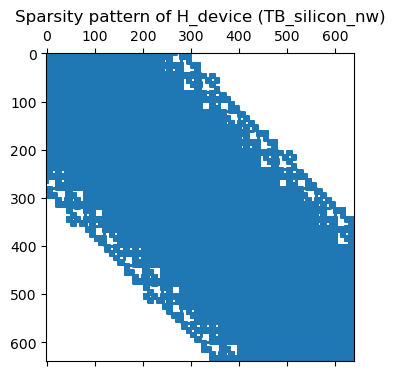

In [20]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load silicon nanowire TB dataset
_data_dir = Path("../DFT_data/TB_silicon_nw").resolve()

# Core NEGF inputs
energy = np.load(_data_dir / "Energy_grid.npy")
energy_abs_ref = np.load(_data_dir / "Energy_grid_absolute.npy")
sigma_L_ref = np.load(_data_dir / "Sigma_L_stack.npy")
sigma_R_ref = np.load(_data_dir / "Sigma_R_stack.npy")
H_left = np.load(_data_dir / "H_left.npy")
S_left = np.load(_data_dir / "S_left.npy")
H_right = np.load(_data_dir / "H_right.npy")
S_right = np.load(_data_dir / "S_right.npy")
H_device = np.load(_data_dir / "H_device.npy")
S_device = np.load(_data_dir / "S_device.npy")

# Build lead principal-layer blocks once
nL = sigma_L_ref.shape[1]
H00_L = H_device[:nL, :nL]
S00_L = S_device[:nL, :nL]
H01_L = H_device[:nL, nL:2*nL]
H10_L = H_device[nL:2*nL, :nL]
S01_L = S_device[:nL, nL:2*nL]
S10_L = S_device[nL:2*nL, :nL]

H00_R = H_device[-nL:, -nL:]
S00_R = S_device[-nL:, -nL:]
H01_R = H_device[-nL:, -2*nL:-nL]
H10_R = H_device[-2*nL:-nL, -nL:]
S01_R = S_device[-nL:, -2*nL:-nL]
S10_R = S_device[-2*nL:-nL, -nL:]
# Structure metadata requested by you
central_coords_angstrom = np.load(_data_dir / "central_coords_angstrom.npy")
central_elements = np.load(_data_dir / "central_elements.npy")
atom_offsets = np.load(_data_dir / "atom_offsets.npy")

# Optional DOS reference exported by ATK
dos_energy_rel_ref = np.load(_data_dir / "DOS_energies_relative.npy")
dos_total_ref = np.load(_data_dir / "DOS_total.npy")

# Quick sanity checks
print(f"Loaded dataset: {_data_dir.name}")
print(f"H_device shape: {H_device.shape}, S_device shape: {S_device.shape}")
print(f"Central region atoms: {len(central_elements)}")

# Visual check of sparsity
plt.figure(figsize=(5, 4))
plt.spy(H_device, markersize=1)
plt.title("Sparsity pattern of H_device (TB_silicon_nw)")
plt.show()

In [21]:
# scaling
V_0 = 0.026          # voltage scale (V)
L_0 = 1.0e-10        # length scale (m), i.e. 1 Å
N_0 = 1e24           # density scale (m^-3)
Nd_physical_val = 1.0e25  # 1e19 cm^-3 (Source/Drain)
ni_physical_val = 1.0e16
Nd_val = Nd_physical_val / N_0

q = 1.609e-19
eps_0 = 8.854e-12
poisson_coeff = (q * N_0 * (L_0**2)) / (eps_0 * V_0)

coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

Lx = float(span[0])
Ly = float(span[1])
Lz = float(span[2])

x_dim = Lx
y_dim = Ly
z_dim = Lz

Nx = 50
Ny = 15
Nz = 15

# material property
eps_si_rel = 11.7

# Applied terminal biases (Volts)
V_applied_left = 0.0
V_applied_right = 0.0

In [22]:
from mpi4py import MPI
from dolfinx import mesh
from dolfinx import fem
import ufl
from dolfinx import default_scalar_type
from dolfinx.fem.petsc import LinearProblem
import pyvista
import pyvista as pv
from dolfinx import plot

pyvista.set_jupyter_backend("static")
pyvista.start_xvfb()

# 3D domain (box): [0,0,0] to [x_dim, y_dim, z_dim]
domain = mesh.create_box(
    MPI.COMM_WORLD,
    [[0.0, 0.0, 0.0], [x_dim, y_dim, z_dim]],
    [Nx, Ny, Nz],
    cell_type=mesh.CellType.tetrahedron,
)
V = fem.functionspace(domain, ("Lagrange", 1)) # this is the potential transformation space
Q = fem.functionspace(domain, ("DG", 0)) # this is piece wise 

/home/nandan_diwan/.conda/envs/negf_env/lib/python3.11/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


In [23]:
from scipy.spatial import cKDTree
from dolfinx import geometry as dfx_geom


class AtomFEMTranslator:
    """Bi-directional translator between atomistic (NEGF) and FEM (dolfinx) grids.

    Atom → FEM:  Gaussian smearing of per-atom scalar values onto DG0 cell grid.
    FEM  → Atom: Point evaluation of a dolfinx Function at atom positions (pooling).

    Parameters
    ----------
    atom_coords_mesh : (N_atoms, 3) ndarray
        Atom positions in the mesh coordinate frame (origin at [0,0,0]).
    domain : dolfinx.mesh.Mesh
    n_orbitals : int
        Total number of orbitals (H_device.shape[0]).
    orbs_per_atom : int or (N_atoms,) array
        Number of basis orbitals per atom.  Scalar → uniform.
    sigma : float or None
        Gaussian smearing width (Å).  If None, median nearest-neighbour distance.
    """

    def __init__(self, atom_coords_mesh, domain, n_orbitals,
                 orbs_per_atom=None, sigma=None):

        self.coords = np.asarray(atom_coords_mesh, dtype=np.float64)
        self.n_atoms = len(self.coords)
        self.n_orbitals = n_orbitals

        # ---- orbital <-> atom mapping ----
        if orbs_per_atom is None:
            orbs_per_atom = n_orbitals // self.n_atoms
        if np.isscalar(orbs_per_atom):
            orbs_per_atom = np.full(self.n_atoms, int(orbs_per_atom), dtype=int)
        self._orbs_per_atom = np.asarray(orbs_per_atom, dtype=int)
        assert self._orbs_per_atom.sum() == n_orbitals, \
            f"sum(orbs_per_atom)={self._orbs_per_atom.sum()} != n_orbitals={n_orbitals}"

        # cumulative offsets  (length n_atoms + 1)
        self.offsets = np.concatenate(([0], np.cumsum(self._orbs_per_atom)))

        # flat array: orbital index → atom index  (for np.bincount)
        self.orbital_to_atom = np.zeros(n_orbitals, dtype=int)
        for j in range(self.n_atoms):
            self.orbital_to_atom[self.offsets[j]:self.offsets[j + 1]] = j

        # ---- Gaussian sigma ----
        if sigma is None:
            tree = cKDTree(self.coords)
            dd, _ = tree.query(self.coords, k=2)
            sigma = float(np.median(dd[:, 1]))
        self.sigma = sigma

        # ---- cell midpoints (atom → FEM smearing) ----
        _tdim = domain.topology.dim
        _n_cells = domain.topology.index_map(_tdim).size_local
        _cells = np.arange(_n_cells, dtype=np.int32)
        self.cell_mids = mesh.compute_midpoints(domain, _tdim, _cells)
        self.n_cells = _n_cells

        # ---- bounding-box tree (FEM → atom evaluation) ----
        bb = dfx_geom.bb_tree(domain, _tdim)
        candidates = dfx_geom.compute_collisions_points(bb, self.coords)
        colliding = dfx_geom.compute_colliding_cells(
            domain, candidates, self.coords)

        self._atom_cells = np.zeros(self.n_atoms, dtype=np.int32)
        _fallback = 0
        for i in range(self.n_atoms):
            links = colliding.links(i)
            if len(links) > 0:
                self._atom_cells[i] = links[0]
            else:
                dists = np.linalg.norm(
                    self.cell_mids - self.coords[i], axis=1)
                self._atom_cells[i] = np.argmin(dists)
                _fallback += 1

        print(f"AtomFEMTranslator: {self.n_atoms} atoms, "
              f"{self.n_cells} cells, {self.n_orbitals} orbitals "
              f"({self._orbs_per_atom[0]}/atom), sigma = {self.sigma:.3f} Å"
              + (f"  ({_fallback} fallback)" if _fallback else ""))

    # ------------------------------------------------------------------ #
    #  orbital <-> atom aggregation                                        #
    # ------------------------------------------------------------------ #
    def orbitals_to_atoms(self, orbital_vals):
        """Sum orbital-resolved values to per-atom values."""
        return np.bincount(self.orbital_to_atom,
                           weights=np.real(orbital_vals),
                           minlength=self.n_atoms)

    def atoms_to_orbitals(self, atom_vals):
        """Expand per-atom values to the orbital basis (constant within each atom)."""
        return np.asarray(atom_vals, dtype=np.float64)[self.orbital_to_atom]

    # ------------------------------------------------------------------ #
    #  atom → FEM  (Gaussian smearing)                                   #
    # ------------------------------------------------------------------ #
    def atom_to_fem(self, atom_values):
        """Gaussian-smear per-atom values onto DG0 cell midpoints.

        f(r_cell) = \sum_i  w_i v_i  /  \sum w_i
        with  w_i = exp( -|r_cell - r_atom_i|² / 2sigma² ).

        Parameters
        ----------
        atom_values : (N_atoms,)

        Returns
        -------
        cell_values : (n_cells,)
        """
        v = np.asarray(atom_values, dtype=np.float64)
        result = np.zeros(self.n_cells, dtype=np.float64)
        norm   = np.zeros(self.n_cells, dtype=np.float64)
        inv_2s2 = 1.0 / (2.0 * self.sigma ** 2)

        for i in range(self.n_atoms):
            d = self.cell_mids - self.coords[i]
            w = np.exp(-np.sum(d * d, axis=1) * inv_2s2)
            result += w * v[i]
            norm   += w

        norm[norm == 0] = 1.0
        return result / norm

    # ------------------------------------------------------------------ #
    #  FEM → atom  (point evaluation / pooling)                          #
    # ------------------------------------------------------------------ #
    def fem_to_atom(self, fem_func):
        """Evaluate a dolfinx Function at each atom position.

        Parameters
        ----------
        fem_func : dolfinx.fem.Function

        Returns
        -------
        atom_values : (N_atoms,)
        """
        vals = fem_func.eval(self.coords, self._atom_cells)
        return np.asarray(vals, dtype=np.float64).flatten()

    # ------------------------------------------------------------------ #
    #  compound helpers                                                  #
    # ------------------------------------------------------------------ #
    def orbital_to_fem(self, orbital_vals):
        """orbital values → atom sum → Gaussian smear to FEM cells."""
        return self.atom_to_fem(self.orbitals_to_atoms(orbital_vals))

    def fem_to_orbital(self, fem_func):
        """FEM function → atom eval → expand to orbital basis."""
        return self.atoms_to_orbitals(self.fem_to_atom(fem_func))


# ------------------------------------------------------------------ #
#  Instantiate                                                       #
# ------------------------------------------------------------------ #
atom_coords_mesh = central_coords_angstrom - central_coords_angstrom.min(axis=0)

translator = AtomFEMTranslator(
    atom_coords_mesh=atom_coords_mesh,
    domain=domain,
    n_orbitals=H_device.shape[0],      # 640
)

# Preparation

AtomFEMTranslator: 128 atoms, 67500 cells, 640 orbitals (5/atom), sigma = 1.480 Å


In [24]:
# --- Build electron count + geometry metadata from dataset arrays ---

# Valence model (symbols + atomic numbers)
_valence_by_symbol = {
    "H": 1.0,
    "C": 4.0,
    "Si": 4.0,
}
_valence_by_Z = {
    1: 1.0,
    6: 4.0,
    14: 4.0,
}

elements = np.asarray(central_elements)
if elements.dtype.kind in {"U", "S", "O"}:
    elements_norm = np.array([str(x) for x in elements])
    unique_el, counts_el = np.unique(elements_norm, return_counts=True)
    missing = [el for el in unique_el if el not in _valence_by_symbol]
    if missing:
        raise ValueError(f"Missing valence mapping for element symbols: {missing}")
    N_val = int(round(sum(_valence_by_symbol[el] * int(c) for el, c in zip(unique_el, counts_el))))
    element_summary = dict(zip(unique_el.tolist(), counts_el.tolist()))
else:
    elements_Z = elements.astype(int)
    unique_Z, counts_Z = np.unique(elements_Z, return_counts=True)
    missing = [int(Z) for Z in unique_Z if int(Z) not in _valence_by_Z]
    if missing:
        raise ValueError(f"Missing valence mapping for atomic numbers: {missing}")
    N_val = int(round(sum(_valence_by_Z[int(Z)] * int(c) for Z, c in zip(unique_Z, counts_Z))))
    element_summary = dict(zip(unique_Z.tolist(), counts_Z.tolist()))

# Geometry info from central_coords_angstrom.npy
coord_min = central_coords_angstrom.min(axis=0)
coord_max = central_coords_angstrom.max(axis=0)
span = coord_max - coord_min

N_val = N_val

print("--- TB_silicon_nw metadata ---")
print(f"Elements in central region: {element_summary}")
print(f"Valence electrons (N_val): {N_val}")
print(f"H_device orbitals: {H_device.shape[0]}")
print(f"Central coordinates span [Å]: x={span[0]:.3f}, y={span[1]:.3f}, z={span[2]:.3f}")
print(f"atom_offsets length: {len(atom_offsets)}")

--- TB_silicon_nw metadata ---
Elements in central region: {'H': 64, 'Si': 64}
Valence electrons (N_val): 320
H_device orbitals: 640
Central coordinates span [Å]: x=8.177, y=8.177, z=21.371
atom_offsets length: 65


In [25]:
fdim = domain.topology.dim - 1

# left/right on z-min/z-max faces (transport along z)
left_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], 0.0)
)
right_facets = mesh.locate_entities_boundary(
    domain, fdim, lambda x: np.isclose(x[2], z_dim)
)

left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
right_dofs = fem.locate_dofs_topological(V, fdim, right_facets)


# n-i-n Doping arrays (DG0)
Nd_norm = fem.Function(Q)
Na_norm = fem.Function(Q)

# Cell centers (local cells)
tdim = domain.topology.dim
num_local_cells = domain.topology.index_map(tdim).size_local
all_cells = np.arange(num_local_cells, dtype=np.int32)
mids = mesh.compute_midpoints(domain, tdim, all_cells)
zm = mids[:, 2]

# Define n-i-n regions (Let's make the channel the middle third for this example)
z_source_end = z_dim / 3.0
z_drain_start = 2.0 * z_dim / 3.0

is_source = zm < z_source_end
is_drain = zm > z_drain_start
is_channel = ~(is_source | is_drain) # Intrinsic region

# Fill DG0 arrays (normalized concentrations)
Nd_array = np.zeros_like(Nd_norm.x.array, dtype=default_scalar_type)
Na_array = np.zeros_like(Na_norm.x.array, dtype=default_scalar_type) # Stays 0 for n-i-n

# Apply Donor doping to Source and Drain regions
Nd_array[all_cells[is_source]] = default_scalar_type(Nd_val)
Nd_array[all_cells[is_drain]] = default_scalar_type(Nd_val)
# Intrinsic channel naturally remains 0.0

Nd_norm.x.array[:] = Nd_array
Na_norm.x.array[:] = Na_array

# Net doping for visualization/debug
net_doping = Nd_norm.x.array.real - Na_norm.x.array.real

In [26]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from negf.gf.recursive_greens_functions import _recursive_inverse
from scipy.interpolate import interp1d

_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

E_grid = np.linspace(-17.0, 10.0, 1201)
nE = len(E_grid)

print(f"Computing DOS + self-energies on grid with {nE} points...")

def _sigma_and_dos_one(i):
    E = float(E_grid[i])

    sigL = sancho_rubio_iterative_greens_function(
        E, h_l=H01_L, h_0=H00_L, h_r=H10_L,
        s_l=S01_L, s_0=S00_L, s_r=S10_L,
        damp=_damp, nconv=_tol,
    )
    sigR = sancho_rubio_iterative_greens_function(
        E, h_l=H01_R, h_0=H00_R, h_r=H10_R,
        s_l=S01_R, s_0=S00_R, s_r=S10_R,
        damp=_damp, nconv=_tol,
    )

    res = _recursive_inverse(
        E, H_device, sigL, sigR,
        compute_lesser=False,
        overlap_matrix=S_device,
        eta=_eta,
        return_trace=True,
        return_diag=False,
        return_gamma=False,
    )

    dos_val = float(-np.imag(res[-1]) / np.pi)
    return i, np.asarray(sigL, dtype=np.complex128), np.asarray(sigR, dtype=np.complex128), dos_val

sigma_L_cache = np.empty((nE, nL, nL), dtype=np.complex128)
sigma_R_cache = np.empty((nE, nL, nL), dtype=np.complex128)
dos_negf = np.empty(nE, dtype=float)

_nproc = 16
_ctx = mp.get_context("fork")
try:
    with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
        for i, sigL, sigR, dos_val in ex.map(
            _sigma_and_dos_one,
            range(nE),
            chunksize=max(1, nE // (_nproc * 4)),
        ):
            sigma_L_cache[i] = sigL
            sigma_R_cache[i] = sigR
            dos_negf[i] = dos_val
except Exception as exc:
    print(f"Parallel run failed ({exc}); falling back to serial.")
    for i in range(nE):
        ii, sigL, sigR, dos_val = _sigma_and_dos_one(i)
        sigma_L_cache[ii] = sigL
        sigma_R_cache[ii] = sigR
        dos_negf[ii] = dos_val

# Persist to external compressed file
sigma_cache_path = (Path.cwd() / "sigma_lead_cache_1201.npz").resolve()
np.savez_compressed(
    sigma_cache_path,
    E_grid=np.asarray(E_grid, dtype=np.float64),
    sigma_L=sigma_L_cache,
    sigma_R=sigma_R_cache,
    meta=np.array(["lead self-energy cache"], dtype=object),
)
print(f"Saved self-energy cache to: {sigma_cache_path}")

def _build_sigma_interp(E_ref, sigma_ref):
    f_re = interp1d(
        E_ref, np.real(sigma_ref), axis=0, kind="linear",
        bounds_error=False, fill_value="extrapolate", assume_sorted=True,
    )
    f_im = interp1d(
        E_ref, np.imag(sigma_ref), axis=0, kind="linear",
        bounds_error=False, fill_value="extrapolate", assume_sorted=True,
    )
    return lambda E_query: np.asarray(f_re(E_query) + 1j * f_im(E_query), dtype=np.complex128)

_sigmaL_interp = _build_sigma_interp(E_grid, sigma_L_cache)
_sigmaR_interp = _build_sigma_interp(E_grid, sigma_R_cache)

def get_sigma_lead(E_query, lead="L", use_interp=True):
    """Return lead self-energy at energy/energies.

    Parameters
    ----------
    E_query : float or array-like
        Energy in eV.
    lead : {'L', 'R'}
        Lead selector.
    use_interp : bool
        True -> linear SciPy interpolation; False -> nearest-grid lookup.

    Returns
    -------
    np.ndarray
        Shape (nL, nL) for scalar E_query, or (nE_query, nL, nL) for vector query.
    """
    lead_key = str(lead).upper()
    if lead_key not in {"L", "R"}:
        raise ValueError("lead must be 'L' or 'R'")

    is_scalar = np.isscalar(E_query)
    E_arr = np.atleast_1d(np.asarray(E_query, dtype=float))

    if use_interp:
        out = _sigmaL_interp(E_arr) if lead_key == "L" else _sigmaR_interp(E_arr)
    else:
        idx_float = np.interp(E_arr, E_grid, np.arange(len(E_grid), dtype=float))
        idx = np.clip(np.rint(idx_float).astype(int), 0, len(E_grid) - 1)
        out = sigma_L_cache[idx] if lead_key == "L" else sigma_R_cache[idx]

    return out[0] if is_scalar else out

def load_sigma_cache_and_build_interpolator(npz_path=sigma_cache_path):
    """Load saved sigma cache file and return a callable accessor."""
    data = np.load(npz_path, allow_pickle=True)
    E_ref = np.asarray(data["E_grid"], dtype=float)
    sigL = np.asarray(data["sigma_L"], dtype=np.complex128)
    sigR = np.asarray(data["sigma_R"], dtype=np.complex128)
    interpL = _build_sigma_interp(E_ref, sigL)
    interpR = _build_sigma_interp(E_ref, sigR)

    def _sigma_from_file(E_query, lead="L"):
        lead_key = str(lead).upper()
        if lead_key not in {"L", "R"}:
            raise ValueError("lead must be 'L' or 'R'")
        is_scalar = np.isscalar(E_query)
        E_arr = np.atleast_1d(np.asarray(E_query, dtype=float))
        out = interpL(E_arr) if lead_key == "L" else interpR(E_arr)
        return out[0] if is_scalar else out

    return _sigma_from_file, E_ref



Computing DOS + self-energies on grid with 1201 points...
Saved self-energy cache to: /home/nandan_diwan/Desktop/NEGF_project/Berkeley-Transport-Simulator/src/device_sims/sigma_lead_cache_1201.npz


In [27]:
_eta = 1e-6
_damp = 1e-6
_tol = 1e-10

E_grid = np.linspace(-17.0, 10.0, 1201)
nE = len(E_grid)


Ev = -6.267547 eV
Ec = -2.397467 eV


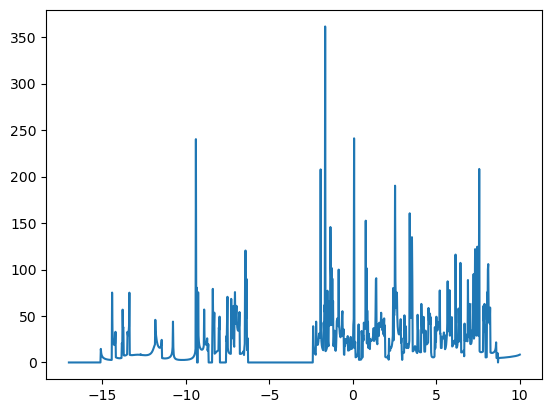

In [28]:
# Band-edge extraction from integrated DOS (IDOS): robust against spiky DOS
E = np.asarray(E_grid, dtype=float)
dos = np.asarray(dos_negf, dtype=float)
n = len(E)
def find_Ec_Ev(E_grid, dos, n ):
    E = E_grid
    # Basic cleanup
    dos_clip = np.maximum(dos, 0.0)
    dE = np.diff(E)
    if np.any(dE <= 0):
        raise ValueError("E_grid must be strictly increasing.")

    # Cumulative trapezoid integral: I(E) = ∫ DOS dE
    idos = np.zeros(n, dtype=float)
    idos[1:] = np.cumsum(0.5 * (dos_clip[1:] + dos_clip[:-1]) * dE)

    # 1) Find a coarse gap using low-DOS segment near center (for I_gap and Ef seed)
    log_eps = max(1e-18, 1e-12 * float(np.max(dos_clip) + 1e-30))
    log_dos = np.log10(dos_clip + log_eps)
    log_low_thresh = np.percentile(log_dos, 30)
    is_low = log_dos <= log_low_thresh

    segments = []
    in_seg = False
    start = 0
    for i, flag in enumerate(is_low):
        if flag and not in_seg:
            start = i
            in_seg = True
        elif (not flag) and in_seg:
            segments.append((start, i - 1))
            in_seg = False
    if in_seg:
        segments.append((start, n - 1))

    interior = [
        (a, b)
        for (a, b) in segments
        if a > int(0.03 * n) and b < int(0.97 * n) and a > 0 and b < n - 1
    ]
    if not interior:
        raise RuntimeError("No interior low-DOS segment found for gap detection.")

    E_mid = 0.5 * (E[0] + E[-1])
    a_gap, b_gap = min(interior, key=lambda t: abs(0.5 * (E[t[0]] + E[t[1]]) - E_mid))
    Ev_coarse = float(E[a_gap - 1])
    Ec_coarse = float(E[b_gap + 1])
    Ef_negf = 0.5 * (Ev_coarse + Ec_coarse)

    # IDOS plateau reference inside the coarse-gap region
    I_gap = float(np.median(idos[a_gap:b_gap + 1]))

    def _cross_ev_from_deltaN(deltaN):
        """Find Ev as rightmost E<Ef where I_gap - I(E) >= deltaN."""
        idx = np.where(E < Ef_negf)[0]
        if len(idx) < 2:
            return np.nan
        F = (I_gap - idos[idx]) - deltaN
        for k in range(len(idx) - 1, 0, -1):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E[idx[k - 1]]
                e1 = E[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e1)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    def _cross_ec_from_deltaN(deltaN):
        """Find Ec as leftmost E>Ef where I(E) - I_gap >= deltaN."""
        idx = np.where(E > Ef_negf)[0]
        if len(idx) < 2:
            return np.nan
        F = (idos[idx] - I_gap) - deltaN
        for k in range(1, len(idx)):
            f0 = F[k - 1]
            f1 = F[k]
            if f0 * f1 <= 0:
                e0 = E[idx[k - 1]]
                e1 = E[idx[k]]
                if abs(f1 - f0) < 1e-20:
                    return float(e0)
                return float(e0 + (0.0 - f0) * (e1 - e0) / (f1 - f0))
        return np.nan

    # 2) Scan deltaN and pick stable Ev/Ec pair (small sensitivity to deltaN)
    idos_span = max(float(idos[-1] - idos[0]), 1e-20)
    deltaN_grid = np.geomspace(1e-6 * idos_span, 2e-3 * idos_span, 25)

    cand = []
    for dN in deltaN_grid:
        Ev_d = _cross_ev_from_deltaN(float(dN))
        Ec_d = _cross_ec_from_deltaN(float(dN))
        if np.isfinite(Ev_d) and np.isfinite(Ec_d) and Ec_d > Ev_d:
            cand.append((float(dN), float(Ev_d), float(Ec_d)))

    if len(cand) < 3:
        Ev = Ev_coarse
        Ec = Ec_coarse
        chosen_deltaN = np.nan
        print("Warning: insufficient IDOS crossing candidates; falling back to coarse edges.")
    else:
        cand = np.array(cand, dtype=float)  # columns: deltaN, Ev, Ec
        Ev_arr = cand[:, 1]
        Ec_arr = cand[:, 2]

        # local stability score from centered finite differences
        score = np.full(len(cand), np.inf, dtype=float)
        for i in range(1, len(cand) - 1):
            dEv = abs(Ev_arr[i + 1] - Ev_arr[i - 1])
            dEc = abs(Ec_arr[i + 1] - Ec_arr[i - 1])
            score[i] = dEv + dEc

        i_best = int(np.argmin(score))
        chosen_deltaN = float(cand[i_best, 0])
        Ev = float(cand[i_best, 1])
        Ec = float(cand[i_best, 2])

    return Ec, Ev

Ec, Ev = find_Ec_Ev(E, dos, n)
Ef0 = (Ec + Ev) / 2

print(f"Ev = {Ev:.6f} eV")
print(f"Ec = {Ec:.6f} eV")
plt.plot(E, dos)



Using in-memory self-energy cache.
Surface DOS computed with multiprocessing (workers=16).


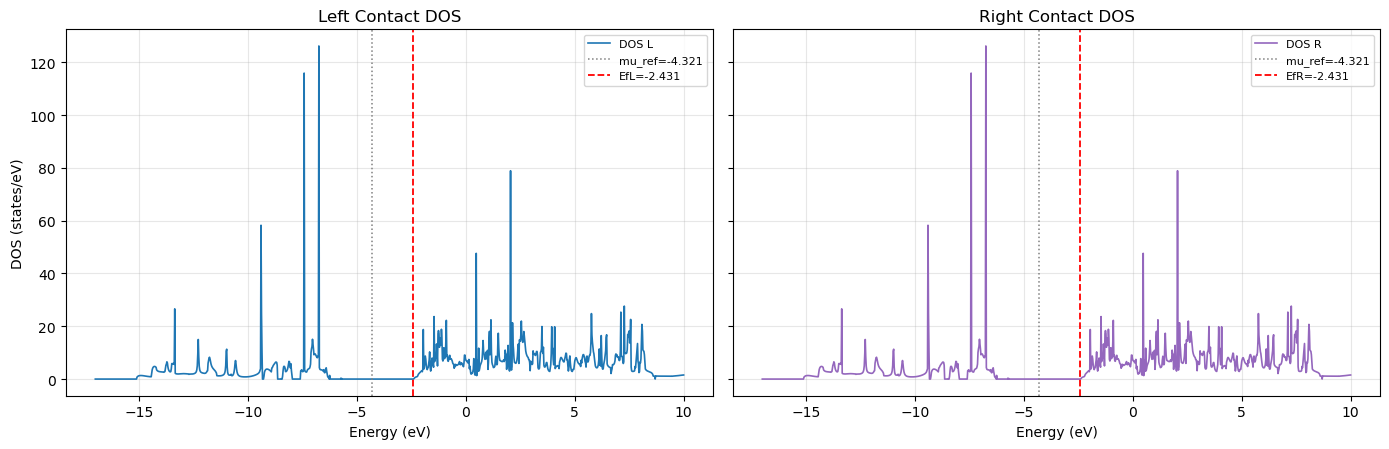

In [29]:
# Simple contact Fermi-level calibration from prescribed doping (no Ef0)
import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

eta_lead = 1e-6
kT_eV = float(V_0)
spin_factor = 2.0
E_cal = np.asarray(E_grid, dtype=float)

def _fd(E, mu, kT):
    x = np.clip((E - mu) / max(kT, 1e-12), -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

# Reuse cached self-energies if present; otherwise load from saved cache
if "sigma_L_cache" in globals() and "sigma_R_cache" in globals() and len(sigma_L_cache) == len(E_cal):
    sigL_stack = np.asarray(sigma_L_cache, dtype=np.complex128)
    sigR_stack = np.asarray(sigma_R_cache, dtype=np.complex128)
    print("Using in-memory self-energy cache.")
else:
    cache_path = Path.cwd() / "sigma_lead_cache_1201.npz"
    cache = np.load(cache_path, allow_pickle=True)
    E_cached = np.asarray(cache["E_grid"], dtype=float)
    if E_cached.shape != E_cal.shape or np.max(np.abs(E_cached - E_cal)) > 1e-12:
        raise ValueError("Cached E_grid does not match current E_grid. Recompute or reload matching cache.")
    sigL_stack = np.asarray(cache["sigma_L"], dtype=np.complex128)
    sigR_stack = np.asarray(cache["sigma_R"], dtype=np.complex128)
    print(f"Loaded self-energy cache from: {cache_path}")

def _surface_dos(E, H00, S00, sigma):
    A = ((float(E) + 1j * eta_lead) * S00 - H00 - sigma).astype(np.complex128)
    lu = spla.splu(sp.csc_matrix(A))
    X = lu.solve(np.asarray(S00, dtype=np.complex128))  # X = G*S
    return float(-np.imag(np.trace(X)) / np.pi)

def _lead_dos_worker(task):
    side, i = task
    if side == "L":
        return i, _surface_dos(E_cal[i], H00_L, S00_L, sigL_stack[i])
    return i, _surface_dos(E_cal[i], H00_R, S00_R, sigR_stack[i])

# Compute left/right lead DOS from cached sigma(E) using multiprocessing
dos_lead_L = np.empty(len(E_cal), dtype=float)
dos_lead_R = np.empty(len(E_cal), dtype=float)
_nproc =16 
_ctx = mp.get_context("fork")
try:
    with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
        tasks_L = (("L", i) for i in range(len(E_cal)))
        for i, val in ex.map(_lead_dos_worker, tasks_L, chunksize=max(1, len(E_cal)//(_nproc*4))):
            dos_lead_L[i] = val
    with ProcessPoolExecutor(max_workers=_nproc, mp_context=_ctx) as ex:
        tasks_R = (("R", i) for i in range(len(E_cal)))
        for i, val in ex.map(_lead_dos_worker, tasks_R, chunksize=max(1, len(E_cal)//(_nproc*4))):
            dos_lead_R[i] = val
    print(f"Surface DOS computed with multiprocessing (workers={_nproc}).")
except Exception as exc:
    print(f"Multiprocessing DOS fallback to serial due to: {exc}")
    dos_lead_L[:] = [
        _surface_dos(E_cal[i], H00_L, S00_L, sigL_stack[i]) for i in range(len(E_cal))
    ]
    dos_lead_R[:] = [
        _surface_dos(E_cal[i], H00_R, S00_R, sigR_stack[i]) for i in range(len(E_cal))
    ]

def _N_of_mu(mu, E, dos, kT):
    occ = _fd(E, mu, kT)
    return float(spin_factor * np.trapezoid(dos * occ, E))

mu_intr = -4.321

N_intr_L = _N_of_mu(mu_intr, E_cal, dos_lead_L, kT_eV)
N_intr_R = _N_of_mu(mu_intr, E_cal, dos_lead_R, kT_eV)

# Convert prescribed physical doping to extra electrons in one lead principal layer
n_atoms_total = max(int(len(atom_offsets) - 1), 1)
atom_vol_m3 = (x_dim * L_0) * (y_dim * L_0) * (z_dim * L_0) / n_atoms_total
offsets = np.asarray(atom_offsets, dtype=int)

n_atoms_left_pl = int(np.count_nonzero(offsets[1:] <= nL))
n_atoms_right_pl = int(np.count_nonzero((H_device.shape[0] - offsets[:-1]) <= nL))
n_atoms_left_pl = max(n_atoms_left_pl, 1)
n_atoms_right_pl = max(n_atoms_right_pl, 1)

V_left_pl = n_atoms_left_pl * atom_vol_m3
V_right_pl = n_atoms_right_pl * atom_vol_m3

Nd_left_phys = float(Nd_physical_val)
Nd_right_phys = float(Nd_physical_val)

dN_target_L = Nd_left_phys * V_left_pl
dN_target_R = Nd_right_phys * V_right_pl
N_target_L = N_intr_L + dN_target_L
N_target_R = N_intr_R + dN_target_R

def _solve_mu_for_target(N_target, E, dos, mu0, kT):
    def f(mu):
        return _N_of_mu(mu, E, dos, kT) - N_target

    a, b = mu0 - 2.0, mu0 + 2.0
    fa, fb = f(a), f(b)
    expand = 0
    while fa * fb > 0 and expand < 10:
        a -= 1.0
        b += 1.0
        fa, fb = f(a), f(b)
        expand += 1

    if fa * fb > 0:
        mu_scan = np.linspace(a, b, 1201)
        vals = np.array([abs(f(m)) for m in mu_scan])
        return float(mu_scan[np.argmin(vals)])

    for _ in range(100):
        m = 0.5 * (a + b)
        fm = f(m)
        if abs(fm) < 1e-10:
            return float(m)
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return float(0.5 * (a + b))

EfL = _solve_mu_for_target(N_target_L, E_cal, dos_lead_L, mu_intr - V_applied_left, kT_eV)
EfR = _solve_mu_for_target(N_target_R, E_cal, dos_lead_R, mu_intr - V_applied_right, kT_eV)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)

axes[0].plot(E_cal, dos_lead_L, color="tab:blue", lw=1.2, label="DOS L")
axes[0].axvline(mu_intr, color="gray", ls=":", lw=1.1, label=f"mu_ref={mu_intr:.3f}")
axes[0].axvline(EfL, color="red", ls="--", lw=1.3, label=f"EfL={EfL:.3f}")
axes[0].set_title("Left Contact DOS")
axes[0].set_xlabel("Energy (eV)")
axes[0].set_ylabel("DOS (states/eV)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(E_cal, dos_lead_R, color="tab:purple", lw=1.2, label="DOS R")
axes[1].axvline(mu_intr, color="gray", ls=":", lw=1.1, label=f"mu_ref={mu_intr:.3f}")
axes[1].axvline(EfR, color="red", ls="--", lw=1.3, label=f"EfR={EfR:.3f}")
axes[1].set_title("Right Contact DOS")
axes[1].set_xlabel("Energy (eV)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
phi_left =  -EfL*0 + V_applied_left
phi_right =  -EfR*0 +  V_applied_right
print(EfL, EfR)

phi_left_norm = phi_left / V_0
phi_right_norm = phi_right / V_0

bc_left = fem.dirichletbc(default_scalar_type(phi_left_norm), left_dofs, V)
bc_right = fem.dirichletbc(default_scalar_type(phi_right_norm), right_dofs, V)
bcs_poisson= [bc_left, bc_right]

-2.4310489310920236 -2.4310489310920236


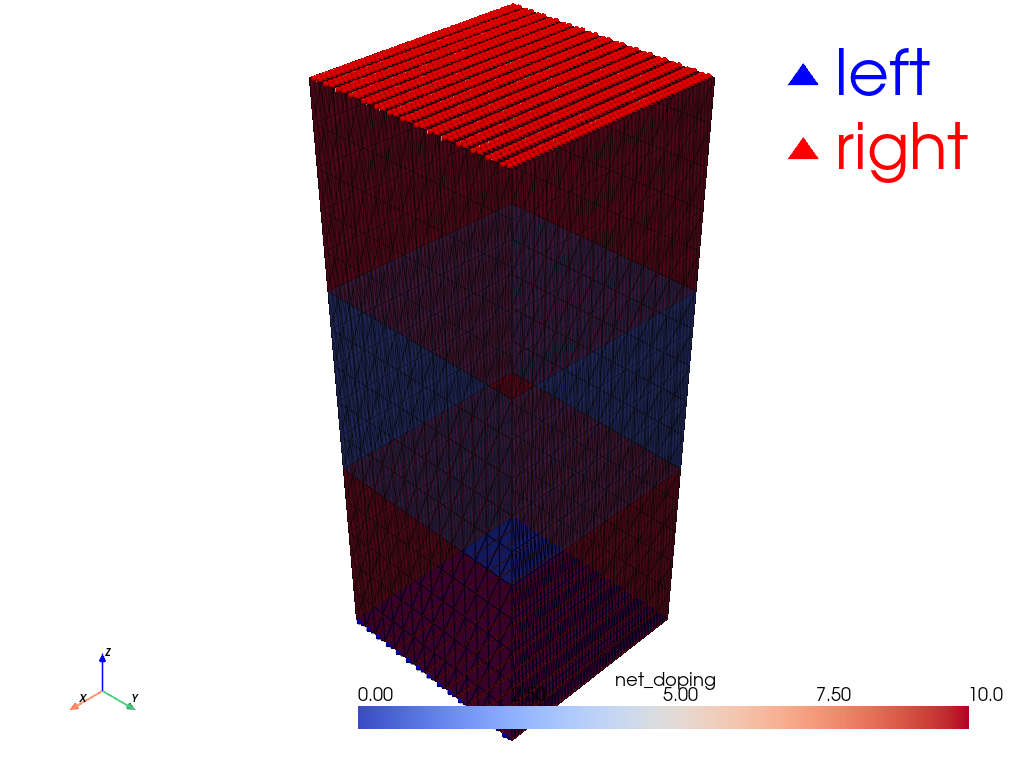

In [31]:
# Minimal visualization: mesh + net doping + BC markers
import pyvista as pv
from dolfinx import plot

# Build VTK grid from mesh topology
topo, cell_types, geom = plot.vtk_mesh(domain, domain.topology.dim)
grid = pv.UnstructuredGrid(topo, cell_types, geom)

# Attach cell-wise net doping (trim if needed)
grid.cell_data["net_doping"] = np.asarray(net_doping[: grid.n_cells], dtype=float)

# Boundary facet midpoints for markers (z-faces)
left_mid = mesh.compute_midpoints(domain, fdim, left_facets)
right_mid = mesh.compute_midpoints(domain, fdim, right_facets)

p = pv.Plotter()
p.add_mesh(grid, scalars="net_doping", show_edges=True, cmap="coolwarm", opacity=0.85)
p.add_points(left_mid, color="blue", point_size=7, render_points_as_spheres=True, label="left")
p.add_points(right_mid, color="red", point_size=7, render_points_as_spheres=True, label="right")
p.add_legend()
p.show_axes()
p.show()

In [32]:
# Initial Poisson solution with nonlinear semiclassical term (stabilized)
from dolfinx.fem.petsc import LinearProblem
import numpy as np
import ufl

# --- BCs and Poisson operator ---
bcs_poisson = [bc_left, bc_right]

eps_rel = fem.Function(Q)
eps_rel.x.array[:] = eps_si_rel

u_psi = ufl.TrialFunction(V)
v_psi = ufl.TestFunction(V)

a_poisson = ufl.inner(eps_rel * ufl.grad(u_psi), ufl.grad(v_psi)) * ufl.dx
L_poisson = fem.Constant(domain, default_scalar_type(0.0)) * v_psi * ufl.dx

# --- 1) Laplace warm-start ---
problem_init = LinearProblem(
    a_poisson, L_poisson, bcs=bcs_poisson,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
    petsc_options_prefix="laplace_initial_presolve",
)
phi_laplace = problem_init.solve()
phi_laplace.name = "psi_laplace"

print(f"Laplace solve done.  ψ range: [{phi_laplace.x.array.min():.4f}, {phi_laplace.x.array.max():.4f}]")
print(f"Potential range: [{phi_laplace.x.array.min()*V_0:.4f}, {phi_laplace.x.array.max()*V_0:.4f}] V")

ni_norm = float(globals().get("ni_norm_val", float(ni_physical_val) / float(N_0)))

# Net doping on DG0 cells: N_net = Nd - Na
N_net_vals = np.asarray(Nd_norm.x.array.real - Na_norm.x.array.real, dtype=float) 

# Optional symbolic form reference (requested)
N_net = Nd_norm - Na_norm

# Local-cell geometry helpers
tdim = domain.topology.dim
num_local_cells = domain.topology.index_map(tdim).size_local
all_cells = np.arange(num_local_cells, dtype=np.int32)
mids = mesh.compute_midpoints(domain, tdim, all_cells)

phi_sc = fem.Function(V)
phi_sc.x.array[:] = phi_laplace.x.array.copy()
phi_sc.name = "psi_poisson_nonlinear"

phi_sc_new = fem.Function(V)
rho_norm_func = fem.Function(Q)
drho_dphi_func = fem.Function(Q)

max_iter = 600
tolerance = 1e-6
max_update = 0.25     # clamp normalized update per step
mix_phi = 0.20        # under-relaxation
phi_nl_clip = 12.0    # avoid overflow in sinh/cosh

prev_err = np.inf
print("Starting Nonlinear Poisson Iteration (stabilized Gummel/Newton)...")

for it in range(max_iter):
    # Evaluate current potential on DG0 cell centers
    phi_vals = phi_sc.eval(mids, all_cells).flatten()
    phi_vals_safe = np.clip(phi_vals, -phi_nl_clip, phi_nl_clip)

    # semiclassical_charge = N_net - 2.0 * ni_norm * sinh(phi)
    rho_vals = N_net_vals.copy()
    rho_vals[:num_local_cells] = N_net_vals[:num_local_cells] - 2.0 * ni_norm * np.sinh(phi_vals_safe[:num_local_cells])

    # Jacobian term: d(rho)/d(phi) = -2.0 * ni_norm * cosh(phi)
    drho_vals = np.zeros(num_local_cells, dtype=float)
    drho_vals[:num_local_cells] = -2.0 * ni_norm * np.cosh(phi_vals_safe[:num_local_cells])

    rho_norm_func.x.array[:] = np.asarray(rho_vals[:len(rho_norm_func.x.array)], dtype=default_scalar_type)
    drho_dphi_func.x.array[:] = np.asarray(drho_vals[:len(drho_dphi_func.x.array)], dtype=default_scalar_type)

    a_gummel = a_poisson - poisson_coeff * drho_dphi_func * u_psi * v_psi * ufl.dx
    L_gummel = poisson_coeff * (rho_norm_func - drho_dphi_func * phi_sc) * v_psi * ufl.dx

    problem_nonlinear = LinearProblem(
        a_gummel, L_gummel, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix=f"poisson_nonlinear_{it}",
    )
    phi_sc_new = problem_nonlinear.solve()

    delta_phi = phi_sc_new.x.array - phi_sc.x.array
    delta_phi = np.clip(delta_phi, -max_update, max_update)
    err = float(np.max(np.abs(delta_phi)))

    # adaptive damping if iteration worsens
    if err > prev_err * 1.05:
        mix_phi = max(0.05, 0.5 * mix_phi)
    elif err < prev_err * 0.8:
        mix_phi = min(0.35, mix_phi * 1.05)

    phi_sc.x.array[:] = phi_sc.x.array + mix_phi * delta_phi
    prev_err = err

    if it % 10 == 0 or err < tolerance:
        print(f"  Iteration {it+1}: |Δψ|_max={err:.4e}, mix={mix_phi:.3f}")

    if err < tolerance:
        print(f"Converged in {it+1} iterations")
        break
else:
    print("WARNING: Reached maximum iterations without converging")

# Canonical output names used downstream
phi_init = phi_sc
phi_init.name = "psi_poisson_nonlinear_init"

# Keep symbolic expression available for diagnostics/post-processing
semiclassical_charge = N_net - 2.0 * ni_norm * ufl.sinh(phi_init)

print(f"Final nonlinear ψ range: [{phi_init.x.array.min():.4f}, {phi_init.x.array.max():.4f}]")
print(f"Final nonlinear potential range: [{phi_init.x.array.min()*V_0:.4f}, {phi_init.x.array.max()*V_0:.4f}] V")

Laplace solve done.  ψ range: [0.0000, 0.0000]
Potential range: [0.0000, 0.0000] V
Starting Nonlinear Poisson Iteration (stabilized Gummel/Newton)...
  Iteration 1: |Δψ|_max=1.5206e-01, mix=0.210
  Iteration 11: |Δψ|_max=6.9902e-03, mix=0.342
  Iteration 21: |Δψ|_max=9.5256e-05, mix=0.350
  Iteration 31: |Δψ|_max=1.2824e-06, mix=0.350
  Iteration 32: |Δψ|_max=8.3357e-07, mix=0.350
Converged in 32 iterations
Final nonlinear ψ range: [0.0000, 0.1521]
Final nonlinear potential range: [0.0000, 0.0040] V


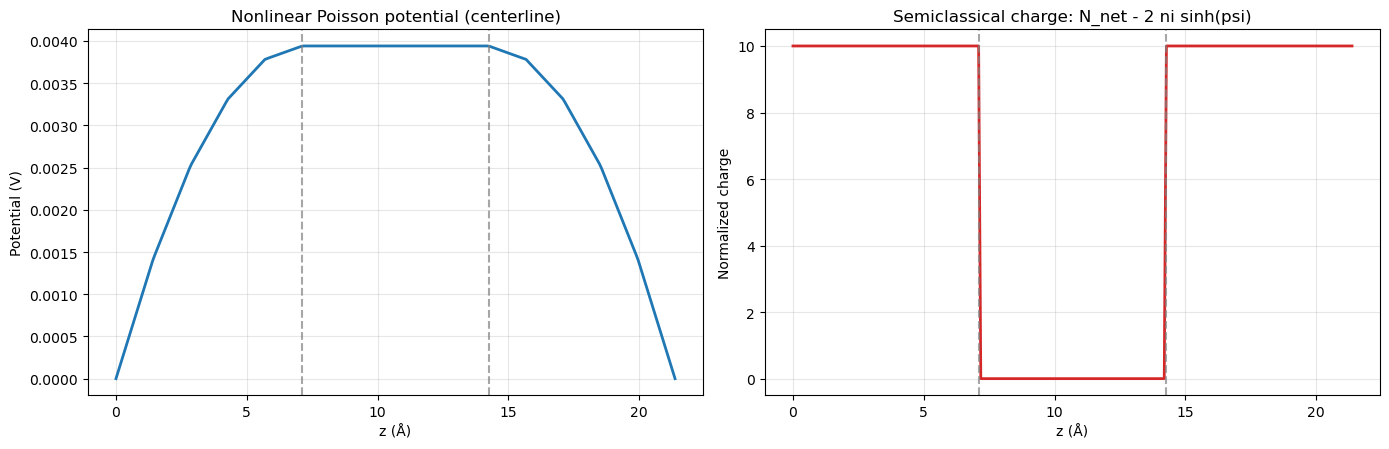

Potential range (V): [0.0000e+00, 3.9410e-03]
Charge range (norm): [-3.0432e-09, 1.0000e+01]


In [37]:
# Plot nonlinear Poisson solution (centerline)
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import geometry as dfx_geom_solver

if "phi_init" not in globals():
    raise RuntimeError("phi_init not found. Run the nonlinear Poisson cell first.")

x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 260)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.asarray(pts_ok)
z_line = pts_ok[:, 2]
psi_line = phi_init.eval(pts_ok, cells_ok).flatten()
V_line = psi_line * V_0

# Nonlinear semiclassical charge along the same line: N_net - 2 ni sinh(psi)
ni_norm = float(globals().get("ni_norm_val", float(ni_physical_val) / float(N_0)))
N_net_cells = np.asarray(Nd_norm.x.array.real - Na_norm.x.array.real, dtype=float)
N_net_line = np.asarray([N_net_cells[c] for c in cells_ok], dtype=float)
rho_sc_line = N_net_line - 2.0 * ni_norm * np.sinh(np.clip(psi_line, -12.0, 12.0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(z_line, V_line, lw=2.0, color="tab:blue")
axes[0].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[0].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[0].set_xlabel("z (Å)")
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Nonlinear Poisson potential (centerline)")
axes[0].grid(alpha=0.3)

axes[1].plot(z_line, rho_sc_line, lw=2.0, color="tab:red")
axes[1].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[1].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("z (Å)")
axes[1].set_ylabel("Normalized charge")
axes[1].set_title("Semiclassical charge: N_net - 2 ni sinh(psi)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Potential range (V): [{V_line.min():.4e}, {V_line.max():.4e}]")
print(f"Charge range (norm): [{rho_sc_line.min():.4e}, {rho_sc_line.max():.4e}]")

In [38]:
# Main NEGF-Poisson Gummel loop (Hamiltonian update: H = H0 - phi only)
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from dolfinx.fem.petsc import LinearProblem
import negf.gf.recursive_greens_functions as rgf

# ---- user controls ----
gummel_max_iter = 260
gummel_tol_phi = 1e-4
mix_phi = 0.25
max_delta_phi = 0.30
_eta_loop = 1e-6

# Fast debug controls
light_mode = False
light_energy_stride = 2
light_max_workers = 16
light_max_iter = 20
light_skip_fd_jacobian = False

# Keep recursive path deterministic in workers
rgf._cpp_recursive = None

def _fd_loop(E, mu, kT):
    x = (E - mu) / max(kT, 1e-12)
    x = np.clip(x, -200.0, 200.0)
    return 1.0 / (1.0 + np.exp(x))

# Initial guess from stabilized nonlinear Poisson pre-solve
phi_gummel = fem.Function(V)
phi_gummel.x.array[:] = phi_init.x.array.copy()

rho_negf_fem = fem.Function(Q)
drho_negf_fem = fem.Function(Q)

# Finite-difference step for d(rho_mobile)/d(phi)
dphi_fd = 0.02

# Convert NEGF electron occupancy -> normalized volumetric mobile charge
box_vol_m3 = (x_dim * L_0) * (y_dim * L_0) * (z_dim * L_0)
atom_vol_m3 = box_vol_m3 / max(int(translator.n_atoms), 1)
atom_norm_scale = atom_vol_m3 * N_0

# Fixed ionic charge term
rho_fixed_cells_norm = np.asarray(
    (Nd_norm.x.array.real - Na_norm.x.array.real)[:len(rho_negf_fem.x.array)],
    dtype=float,
)

# Orbital map once (for phi projection to Hamiltonian diagonal)
atom_z_loop = np.asarray(atom_coords_mesh[:, 2], dtype=float)
orb_z_loop = np.zeros(H_device.shape[0], dtype=float)
offsets_use_loop = np.asarray(translator.offsets if hasattr(translator, "offsets") else atom_offsets, dtype=int)
n_map_loop = min(len(atom_z_loop), max(len(offsets_use_loop) - 1, 0))
for a in range(n_map_loop):
    i0 = int(offsets_use_loop[a])
    i1 = int(offsets_use_loop[a + 1])
    orb_z_loop[i0:i1] = atom_z_loop[a]

diag_idx = np.diag_indices(H_device.shape[0])

# Chemical potentials (simple convention used in this notebook)
mu_left = float(EfL - V_applied_left)
mu_right = float(EfR - V_applied_right)
mu_eq = mu_right

kbT_eff = float(V_0)

def shift_sigma_cache(sigma_cache, E_grid, shift_eV):
    E_target = E_grid + shift_eV
    interp_real = interp1d(E_grid, np.real(sigma_cache), axis=0, fill_value="extrapolate")
    interp_imag = interp1d(E_grid, np.imag(sigma_cache), axis=0, fill_value="extrapolate")
    return interp_real(E_target) + 1j * interp_imag(E_target)

shift_L_eV = float(phi_left)
shift_R_eV = float(phi_right)

if light_mode:
    loop_idx = np.arange(0, len(E_grid), light_energy_stride, dtype=int)
    E_grid_loop = np.asarray(E_grid[loop_idx], dtype=float)
    sigma_L_shifted_full = shift_sigma_cache(sigma_L_cache, E_grid, shift_L_eV)
    sigma_R_shifted_full = shift_sigma_cache(sigma_R_cache, E_grid, shift_R_eV)
    sigma_L_loop = [sigma_L_shifted_full[i] for i in loop_idx]
    sigma_R_loop = [sigma_R_shifted_full[i] for i in loop_idx]
    gummel_iter_use = min(gummel_max_iter, light_max_iter)
else:
    loop_idx = np.arange(len(E_grid), dtype=int)
    E_grid_loop = np.asarray(E_grid, dtype=float)
    sigma_L_loop = shift_sigma_cache(sigma_L_cache, E_grid, shift_L_eV)
    sigma_R_loop = shift_sigma_cache(sigma_R_cache, E_grid, shift_R_eV)
    gummel_iter_use = gummel_max_iter

print("Starting main NEGF-Poisson Gummel loop...")
prev_err_phi = np.inf

for g_it in range(gummel_iter_use):
    # 1) Hamiltonian update from current mixed potential: H = H0 - phi
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)
    phi_orb_loop_eV = phi_orb_loop * V_0

    H_device_biased = np.array(H_device, copy=True)
    H_device_biased[diag_idx] = H_device[diag_idx] - phi_orb_loop_eV

    # 2) NEGF charge at current potential
    dE_loop = np.gradient(E_grid_loop)
    n_orb = H_device_biased.shape[0]
    rho_eq_orb = np.zeros(n_orb, dtype=float)
    rho_neq_orb = np.zeros(n_orb, dtype=float)

    def _charge_contrib_loop(i_loop):
        from negf.gf.recursive_greens_functions import _recursive_inverse
        E = float(E_grid_loop[i_loop])
        sigL = sigma_L_loop[i_loop]
        sigR = sigma_R_loop[i_loop]

        fL = _fd_loop(E, mu_left, kbT_eff)
        fR = _fd_loop(E, mu_right, kbT_eff)
        fEq = _fd_loop(E, mu_eq, kbT_eff)

        out_tot = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fL, occ_right=fR,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )
        out_eq = _recursive_inverse(
            E, H_device_biased, sigL, sigR,
            compute_lesser=True,
            occ_left=fEq, occ_right=fEq,
            overlap_matrix=S_device,
            eta=_eta_loop,
            return_trace=False,
            return_diag=True,
            return_gamma=True,
        )

        g_less_tot = np.asarray(out_tot[1])
        g_less_eq = np.asarray(out_eq[1])
        pref = 1.0 / (2.0 * np.pi)
        nE_tot = np.real(g_less_tot) * pref
        nE_eq = np.real(g_less_eq) * pref
        return i_loop, nE_eq, (nE_tot - nE_eq)

    max_workers = 16

    try:
        with ProcessPoolExecutor(max_workers=max_workers) as pool:
            for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop, range(len(E_grid_loop))):
                w = dE_loop[i_loop]
                rho_eq_orb += nE_eq * w
                rho_neq_orb += nE_neq * w
    except Exception as exc:
        print(f"  Parallel NEGF charge fallback to serial due to: {exc}")
        for i_loop in range(len(E_grid_loop)):
            _, nE_eq, nE_neq = _charge_contrib_loop(i_loop)
            w = dE_loop[i_loop]
            rho_eq_orb += nE_eq * w
            rho_neq_orb += nE_neq * w

    rho_tot_orb = rho_eq_orb + rho_neq_orb
    rho_tot_atom = translator.orbitals_to_atoms(rho_tot_orb)

    # 3) Compose Poisson RHS charge: mobile + fixed ionic
    rho_mobile_atom_norm = -rho_tot_atom / max(atom_norm_scale, 1e-30)
    rho_mobile_cells = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm), dtype=float)
    rho_cells_total = rho_mobile_cells + rho_fixed_cells_norm

    rho_negf_fem.x.array[:] = np.asarray(
        rho_cells_total[:len(rho_negf_fem.x.array)],
        dtype=default_scalar_type,
    )

    # 4) Nonlinear Poisson linearization term d(rho_mobile)/d(phi)
    if light_mode and light_skip_fd_jacobian:
        drho_negf_fem.x.array[:] = 0.0
    else:
        phi_gummel_pert = fem.Function(V)
        phi_gummel_pert.x.array[:] = phi_gummel.x.array + dphi_fd

        # Perturbed Hamiltonian: H = H0 - (phi + dphi)
        phi_atom_pert = translator.fem_to_atom(phi_gummel_pert)
        phi_orb_pert = translator.atoms_to_orbitals(phi_atom_pert)
        phi_orb_pert_eV = phi_orb_pert * V_0

        H_device_pert = np.array(H_device, copy=True)
        H_device_pert[diag_idx] = H_device[diag_idx] - phi_orb_pert_eV

        rho_eq_orb_pert = np.zeros(n_orb, dtype=float)
        rho_neq_orb_pert = np.zeros(n_orb, dtype=float)

        def _charge_contrib_loop_pert(i_loop):
            from negf.gf.recursive_greens_functions import _recursive_inverse
            E = float(E_grid_loop[i_loop])
            sigL = sigma_L_loop[i_loop]
            sigR = sigma_R_loop[i_loop]

            fL = _fd_loop(E, mu_left, kbT_eff)
            fR = _fd_loop(E, mu_right, kbT_eff)
            fEq = _fd_loop(E, mu_eq, kbT_eff)

            out_tot = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fL, occ_right=fR,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )
            out_eq = _recursive_inverse(
                E, H_device_pert, sigL, sigR,
                compute_lesser=True,
                occ_left=fEq, occ_right=fEq,
                overlap_matrix=S_device,
                eta=_eta_loop,
                return_trace=False,
                return_diag=True,
                return_gamma=True,
            )

            g_less_tot = np.asarray(out_tot[1])
            g_less_eq = np.asarray(out_eq[1])
            pref = 1.0 / (2.0 * np.pi)
            nE_tot = np.real(g_less_tot) * pref
            nE_eq = np.real(g_less_eq) * pref
            return i_loop, nE_eq, (nE_tot - nE_eq)

        try:
            with ProcessPoolExecutor(max_workers=max_workers) as pool:
                for i_loop, nE_eq, nE_neq in pool.map(_charge_contrib_loop_pert, range(len(E_grid_loop))):
                    w = dE_loop[i_loop]
                    rho_eq_orb_pert += nE_eq * w
                    rho_neq_orb_pert += nE_neq * w
        except Exception:
            for i_loop in range(len(E_grid_loop)):
                _, nE_eq, nE_neq = _charge_contrib_loop_pert(i_loop)
                w = dE_loop[i_loop]
                rho_eq_orb_pert += nE_eq * w
                rho_neq_orb_pert += nE_neq * w

        rho_tot_atom_pert = translator.orbitals_to_atoms(rho_eq_orb_pert + rho_neq_orb_pert)
        rho_mobile_atom_norm_pert = -rho_tot_atom_pert / max(atom_norm_scale, 1e-30)
        rho_mobile_cells_pert = np.asarray(translator.atom_to_fem(rho_mobile_atom_norm_pert), dtype=float)
        drho_cells = (rho_mobile_cells_pert - rho_mobile_cells) / dphi_fd

        # Stabilize Jacobian
        drho_cells = np.clip(drho_cells, -50.0, 0.0)
        drho_negf_fem.x.array[:] = np.asarray(
            drho_cells[:len(drho_negf_fem.x.array)],
            dtype=default_scalar_type,
        )

    # 5) Solve nonlinear Poisson update (linearized)
    a_gummel_negf = a_poisson - poisson_coeff * drho_negf_fem * u_psi * v_psi * ufl.dx
    L_gummel_negf = poisson_coeff * (rho_negf_fem - drho_negf_fem * phi_gummel) * v_psi * ufl.dx

    problem_negf_poisson = LinearProblem(
        a_gummel_negf, L_gummel_negf, bcs=bcs_poisson,
        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
        petsc_options_prefix=f"negf_poisson_gummel_{g_it}",
    )
    phi_candidate = problem_negf_poisson.solve()

    # 6) Clamped mixed update
    delta_phi = phi_candidate.x.array - phi_gummel.x.array
    delta_phi = np.clip(delta_phi, -max_delta_phi, max_delta_phi)
    phi_next = phi_gummel.x.array + mix_phi * delta_phi

    err_phi = float(np.max(np.abs(phi_next - phi_gummel.x.array)))

    # Adaptive damping
    if err_phi > prev_err_phi * 1.05:
        mix_phi = max(0.05, 0.5 * mix_phi)
    elif err_phi < prev_err_phi * 0.8:
        mix_phi = min(0.35, mix_phi * 1.05)
    prev_err_phi = err_phi

    phi_gummel.x.array[:] = phi_next

    # Keep canonical variables updated
    phi_new = fem.Function(V)
    phi_new.x.array[:] = phi_gummel.x.array

    # refresh biased Hamiltonian with latest phi
    phi_atom_loop = translator.fem_to_atom(phi_gummel)
    phi_orb_loop = translator.atoms_to_orbitals(phi_atom_loop)
    phi_orb_loop_eV = phi_orb_loop * V_0
    H_device_biased[diag_idx] = H_device[diag_idx] - phi_orb_loop_eV

    bc_drop_norm = abs(float(phi_left_norm - phi_right_norm)) if "phi_left_norm" in globals() and "phi_right_norm" in globals() else np.nan
    charge_drive_est = float((poisson_coeff / max(eps_si_rel, 1e-30)) * np.max(np.abs(rho_cells_total)))
    print(
        f"  Gummel {g_it+1:03d}: |Δphi|_max={err_phi:.3e}, mix={mix_phi:.3f}, "
        f"rho_mobile=[{rho_mobile_cells.min():.3e}, {rho_mobile_cells.max():.3e}], "
        f"rho_total=[{rho_cells_total.min():.3e}, {rho_cells_total.max():.3e}], "
        f"BCdrop={bc_drop_norm:.3e}, charge_drive~{charge_drive_est:.3e}"
    )

    if err_phi < gummel_tol_phi:
        print(f"Converged in {g_it+1} Gummel iterations")
        break
else:
    print("Reached max Gummel iterations without full convergence")

print(
    f"Final mixed potential range (normalized): "
    f"[{phi_gummel.x.array.min():.4e}, {phi_gummel.x.array.max():.4e}]"
)
print("Hamiltonian updated from final mixed potential (H_device_biased ready).")

Starting main NEGF-Poisson Gummel loop...
  Gummel 001: |Δphi|_max=7.500e-02, mix=0.263, rho_mobile=[-1.277e+05, -1.720e+04], rho_total=[-1.277e+05, -1.719e+04], BCdrop=0.000e+00, charge_drive~7.629e+01
  Gummel 002: |Δphi|_max=7.875e-02, mix=0.131, rho_mobile=[-1.280e+05, -1.718e+04], rho_total=[-1.280e+05, -1.717e+04], BCdrop=0.000e+00, charge_drive~7.645e+01
  Gummel 003: |Δphi|_max=3.938e-02, mix=0.138, rho_mobile=[-1.282e+05, -1.713e+04], rho_total=[-1.282e+05, -1.712e+04], BCdrop=0.000e+00, charge_drive~7.659e+01
  Gummel 004: |Δphi|_max=4.134e-02, mix=0.138, rho_mobile=[-1.283e+05, -1.709e+04], rho_total=[-1.283e+05, -1.708e+04], BCdrop=0.000e+00, charge_drive~7.664e+01
  Gummel 005: |Δphi|_max=4.134e-02, mix=0.138, rho_mobile=[-1.284e+05, -1.705e+04], rho_total=[-1.283e+05, -1.704e+04], BCdrop=0.000e+00, charge_drive~7.667e+01
  Gummel 006: |Δphi|_max=4.134e-02, mix=0.138, rho_mobile=[-1.284e+05, -1.701e+04], rho_total=[-1.284e+05, -1.700e+04], BCdrop=0.000e+00, charge_drive~7.

KeyboardInterrupt: 

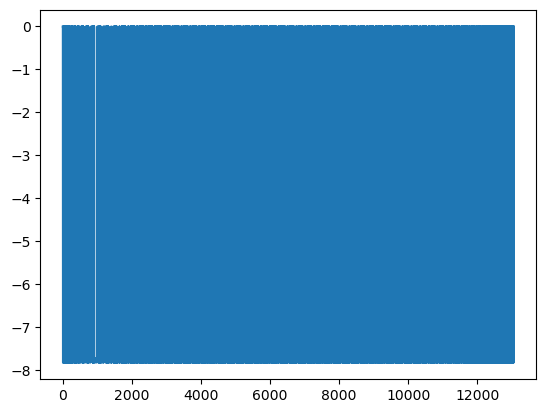

In [39]:
plt.plot(phi_gummel.x.array)

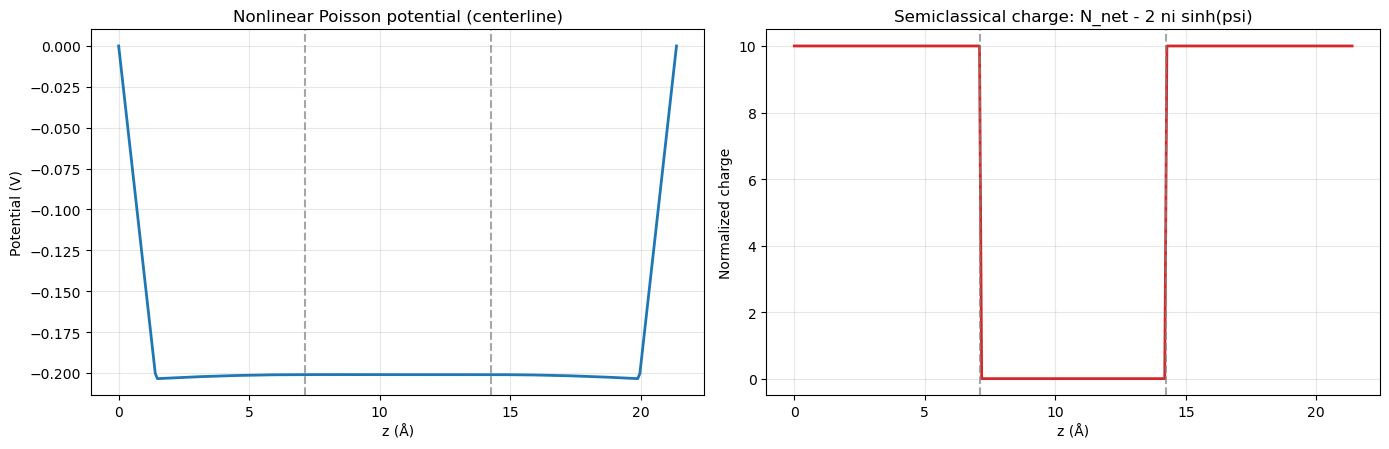

Potential range (V): [-2.0349e-01, 0.0000e+00]
Charge range (norm): [2.2790e-05, 1.0000e+01]


In [40]:
# Plot nonlinear Poisson solution (centerline)
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import geometry as dfx_geom_solver

if "phi_init" not in globals():
    raise RuntimeError("phi_init not found. Run the nonlinear Poisson cell first.")

x_mid, y_mid = x_dim / 2.0, y_dim / 2.0
z_pts = np.linspace(0.0, z_dim, 260)
probe_pts = np.column_stack([
    np.full_like(z_pts, x_mid),
    np.full_like(z_pts, y_mid),
    z_pts,
])

bb = dfx_geom_solver.bb_tree(domain, domain.topology.dim)
cell_cands = dfx_geom_solver.compute_collisions_points(bb, probe_pts)
colliding = dfx_geom_solver.compute_colliding_cells(domain, cell_cands, probe_pts)

pts_ok, cells_ok = [], []
for i in range(len(probe_pts)):
    links = colliding.links(i)
    if len(links) > 0:
        pts_ok.append(probe_pts[i])
        cells_ok.append(links[0])

pts_ok = np.asarray(pts_ok)
z_line = pts_ok[:, 2]
psi_line = phi_gummel.eval(pts_ok, cells_ok).flatten()
V_line = psi_line * V_0

# Nonlinear semiclassical charge along the same line: N_net - 2 ni sinh(psi)
ni_norm = float(globals().get("ni_norm_val", float(ni_physical_val) / float(N_0)))
N_net_cells = np.asarray(Nd_norm.x.array.real - Na_norm.x.array.real, dtype=float)
N_net_line = np.asarray([N_net_cells[c] for c in cells_ok], dtype=float)
rho_sc_line = N_net_line - 2.0 * ni_norm * np.sinh(np.clip(psi_line, -12.0, 12.0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(z_line, V_line, lw=2.0, color="tab:blue")
axes[0].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[0].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[0].set_xlabel("z (Å)")
axes[0].set_ylabel("Potential (V)")
axes[0].set_title("Nonlinear Poisson potential (centerline)")
axes[0].grid(alpha=0.3)

axes[1].plot(z_line, rho_sc_line, lw=2.0, color="tab:red")
axes[1].axvline(z_source_end, color="gray", ls="--", alpha=0.7)
axes[1].axvline(z_drain_start, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("z (Å)")
axes[1].set_ylabel("Normalized charge")
axes[1].set_title("Semiclassical charge: N_net - 2 ni sinh(psi)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Potential range (V): [{V_line.min():.4e}, {V_line.max():.4e}]")
print(f"Charge range (norm): [{rho_sc_line.min():.4e}, {rho_sc_line.max():.4e}]")